In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm

from sklearn.datasets import make_blobs



In [29]:
make_blobs

<function sklearn.datasets._samples_generator.make_blobs(n_samples=100, n_features=2, *, centers=None, cluster_std=1.0, center_box=(-10.0, 10.0), shuffle=True, random_state=None, return_centers=False)>

In [30]:
X,y = make_blobs(n_samples=40, centers=2, random_state=20)
X,y

(array([[ 1.71842122,  9.52190711],
        [ 9.13204399,  5.32194764],
        [ 8.68770841,  7.79789319],
        [ 2.8137247 ,  8.36064298],
        [ 7.27542879,  6.31825811],
        [ 0.48311336,  8.19998973],
        [ 7.9294032 ,  6.08842852],
        [ 2.69548237, 10.01411256],
        [ 2.26571286,  8.36068903],
        [ 0.82767806,  6.34128434],
        [ 0.87712287,  6.84969507],
        [ 6.86839861,  5.83429863],
        [ 0.97059923,  7.11190662],
        [ 2.12015254,  5.61101265],
        [ 2.88274828,  9.28705277],
        [ 8.47704476,  6.80415251],
        [ 7.61095347,  7.8201477 ],
        [ 1.65359865,  9.510461  ],
        [ 2.08607703,  7.46086368],
        [ 9.92527993,  6.67617854],
        [ 2.09222936,  6.81774802],
        [ 1.59396992,  4.76457177],
        [ 0.67778343,  8.51397085],
        [ 7.86880706,  7.3062361 ],
        [ 8.32405183,  3.6123843 ],
        [ 8.35834306,  6.47258777],
        [ 2.28968574,  6.40317382],
        [ 6.34822954,  5.460

In [31]:
clf = svm.SVC(kernel='linear', C=1)
clf.fit(X,y)

SVC(C=1, kernel='linear')

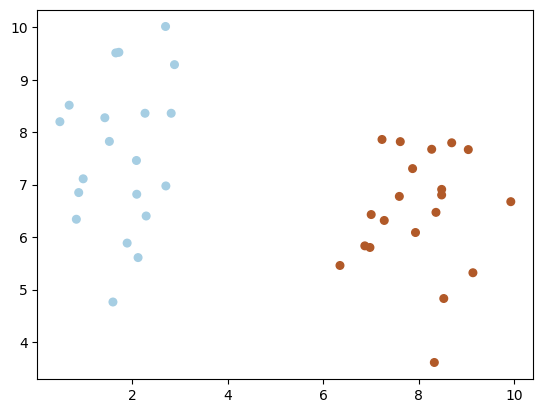

In [32]:
plt.scatter(X[:,0], X[:,1], c=y, s=30, cmap=plt.cm.Paired)
plt.show()

In [33]:
new_data = [[3,4], [5,6]]
print(clf.predict(new_data))


[0 1]


In [34]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X,y = iris.data, iris.target
X_train , X_test , y_train , y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [35]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [36]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
model = RandomForestClassifier(n_estimators=100)

In [38]:
model.fit(X_train_scaled, y_train)


RandomForestClassifier()

In [39]:
y_preds = model.predict(X_test_scaled)
y_preds

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [40]:
from sklearn.metrics import classification_report, accuracy_score
print(f"Accuracy: {accuracy_score(y_test, y_preds) * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_preds , target_names=iris.target_names))

Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [41]:
import seaborn as sns

<Axes: >

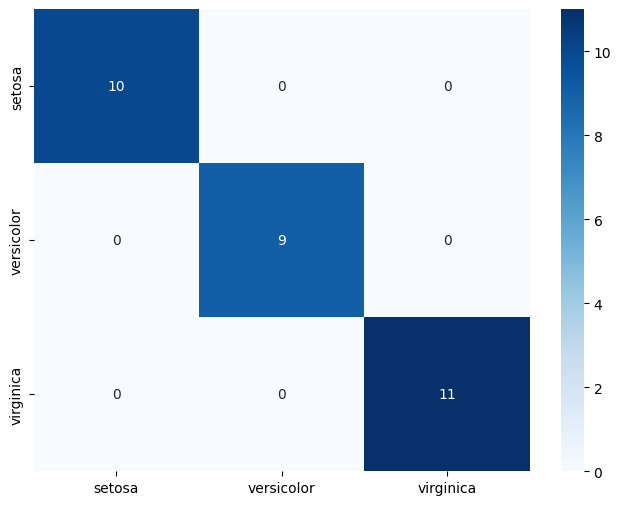

In [42]:
cm = confusion_matrix(y_test, y_preds)
plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names)


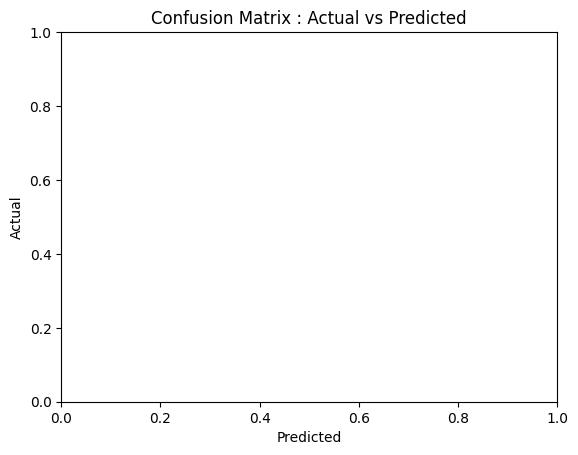

In [43]:
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix : Actual vs Predicted")
plt.show()

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

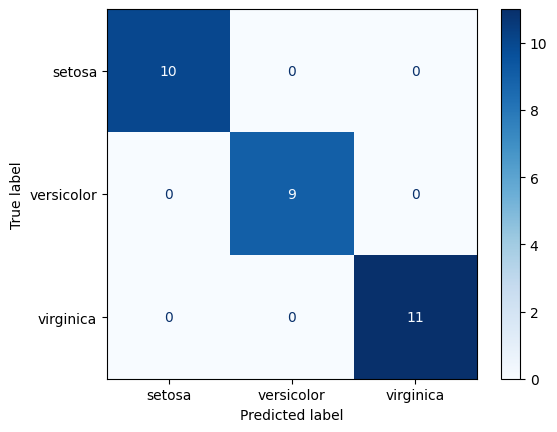

In [45]:
ConfusionMatrixDisplay.from_predictions(y_test, y_preds, display_labels=iris.target_names, cmap=plt.cm.Blues)

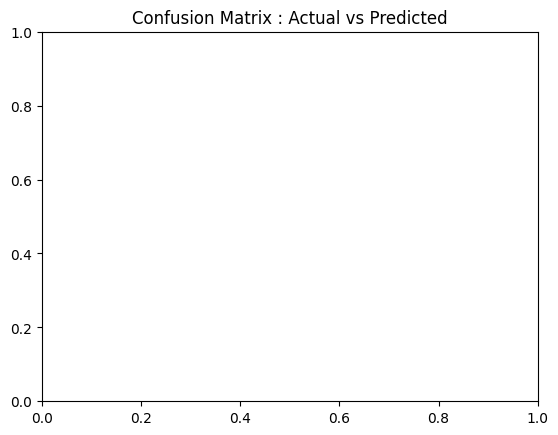

In [46]:
plt.title("Confusion Matrix : Actual vs Predicted")
plt.show()